# 02 - Preprocessing & Feature Engineering

This notebook turns raw data into a model-ready feature matrix. Every decision is documented with a rationale.

1. Remove outliers identified in EDA
2. Impute missing values (domain-aware strategy)
3. Feature engineering - 15 new features
4. Encoding ordinal, label, target
5. Skewness correction
6. Scaling
7. Verify the final feature matrix
8. Save processed data for modeling

In [10]:
import sys
import os
import importlib.util
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import RobustScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')
os.makedirs('../plots', exist_ok=True)

def load_module(name, path):
    spec = importlib.util.spec_from_file_location(name, os.path.abspath(path))
    mod  = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

features   = load_module("features",   "../src/features.py")
preprocess = load_module("preprocess", "../src/preprocess.py")

engineer_features   = features.engineer_features
impute_missing      = preprocess.impute_missing
encode_ordinals     = preprocess.encode_ordinals
encode_categoricals = preprocess.encode_categoricals
fix_skewness        = preprocess.fix_skewness
QUALITY_MAP         = preprocess.QUALITY_MAP

plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'#f9f9f9',
    'axes.grid':True,'grid.alpha':0.35,'axes.spines.top':False,'axes.spines.right':False,
    'font.size':11,'axes.titlesize':13,'axes.titleweight':'bold'
})
C = ['#4C6EF5','#F76707','#2F9E44','#E03131','#7950F2','#1098AD']

train = pd.read_csv('../data/train.csv')
test  = pd.read_csv('../data/test.csv')
print(f'Raw train: {train.shape}  |  test: {test.shape}')

Raw train: (1460, 81)  |  test: (1459, 80)


## 1. Remove Outliers

In [11]:
# Two partial-sale outliers identified in EDA
# GrLivArea > 4000 AND SalePrice < $300K are non-arms-length transactions
before = len(train)
train = train[~((train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000))].reset_index(drop=True)
print(f'Removed {before - len(train)} outlier rows. Train size: {len(train)}')

y = np.log1p(train['SalePrice'])
train_ids = train['Id']
test_ids  = test['Id']

Removed 2 outlier rows. Train size: 1458


## 2. Combine & Impute

In [12]:
n_train = len(train)
all_data = pd.concat([
    train.drop(['SalePrice','Id'], axis=1),
    test.drop('Id', axis=1)
], axis=0).reset_index(drop=True)

print(f'Combined shape before imputation: {all_data.shape}')
print(f'Total missing values: {all_data.isnull().sum().sum()}')

all_data = impute_missing(all_data)
print(f'Total missing values after imputation: {all_data.isnull().sum().sum()}')

Combined shape before imputation: (2917, 79)
Total missing values: 15700
Total missing values after imputation: 0


## 3. Feature Engineering

In [13]:
before_cols = set(all_data.columns)
all_data = engineer_features(all_data)
new_cols = set(all_data.columns) - before_cols
print(f'New features added ({len(new_cols)}):')
for col in sorted(new_cols):
    print(f'  {col}')
print(f'\nTotal features: {all_data.shape[1]}')

New features added (19):
  GarageAge
  GarageScore
  Has2ndFloor
  HasBsmt
  HasFireplace
  HasGarage
  HasPool
  HasPorch
  HouseAge
  IsNewHouse
  IsRemodeled
  NeighborhoodTier
  QualxLivArea
  QualxSF
  RemodelAge
  TotalBathrooms
  TotalLivingArea
  TotalPorchSF
  TotalSF

Total features: 98


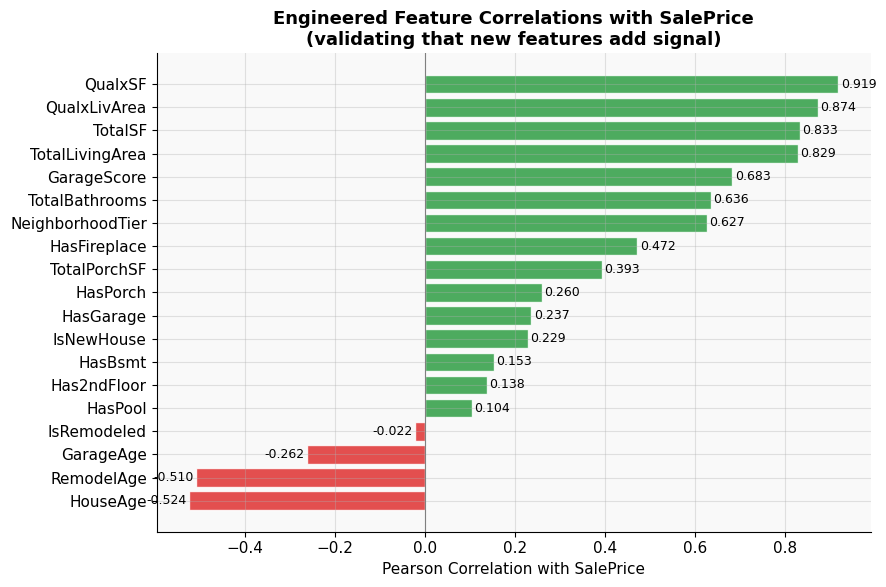

In [14]:
# Validate new features correlate with target
train_fe = all_data.iloc[:n_train].copy()
train_fe['SalePrice'] = train['SalePrice'].values

new_corrs = {}
for col in sorted(new_cols):
    if col in train_fe.select_dtypes(include=np.number).columns:
        corr = train_fe[col].corr(train_fe['SalePrice'])
        new_corrs[col] = corr

new_corr_df = pd.Series(new_corrs).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
colors_nc = [C[2] if v > 0 else C[3] for v in new_corr_df.values]
ax.barh(new_corr_df.index[::-1], new_corr_df.values[::-1], color=colors_nc[::-1], edgecolor='white', alpha=0.85)
ax.axvline(0, color='gray', lw=0.8)
ax.set_xlabel('Pearson Correlation with SalePrice')
ax.set_title('Engineered Feature Correlations with SalePrice\n(validating that new features add signal)')
for i, v in enumerate(new_corr_df.values[::-1]):
    ax.text(v + (0.005 if v >= 0 else -0.005), i, f'{v:.3f}', va='center',
            ha='left' if v >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.savefig('../plots/10_engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Encoding

Ordinal encoding applied. Quality map: {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}


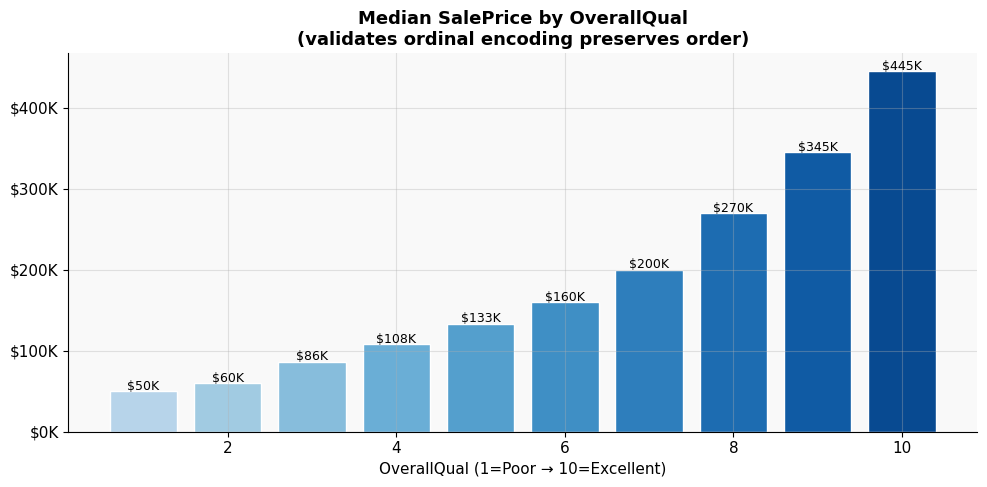

In [15]:
# Step 1: Ordinal encoding for quality/condition columns
all_data = encode_ordinals(all_data)
print('Ordinal encoding applied. Quality map:', QUALITY_MAP)

# Step 2: Visualize what ordinal encoding does to a key column
sample = all_data.iloc[:n_train][['OverallQual']].copy()
sample['SalePrice'] = train['SalePrice'].values

fig, ax = plt.subplots(figsize=(10, 5))
qual_medians = sample.groupby('OverallQual')['SalePrice'].median()
ax.bar(qual_medians.index, qual_medians.values, color=plt.cm.Blues(np.linspace(0.3, 0.9, len(qual_medians))),
       edgecolor='white')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
ax.set_xlabel('OverallQual (1=Poor → 10=Excellent)')
ax.set_title('Median SalePrice by OverallQual\n(validates ordinal encoding preserves order)')
for i, (q, v) in enumerate(qual_medians.items()):
    ax.text(q, v + 2000, f'${v/1e3:.0f}K', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../plots/11_ordinal_encoding.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Skewness Correction

  Log-transformed 39 skewed features (threshold=0.75)


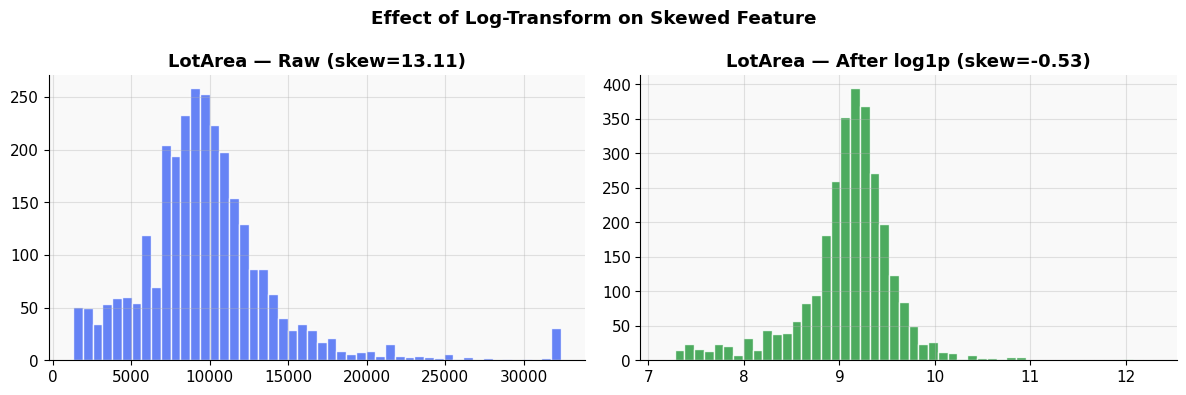

In [16]:
# Show before/after for a highly skewed feature
example_feat = 'LotArea'
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(all_data[example_feat].clip(0, all_data[example_feat].quantile(0.99)),
             bins=50, color=C[0], edgecolor='white', alpha=0.85)
axes[0].set_title(f'{example_feat} — Raw (skew={stats.skew(all_data[example_feat]):.2f})')

all_data = fix_skewness(all_data, threshold=0.75)

axes[1].hist(all_data[example_feat], bins=50, color=C[2], edgecolor='white', alpha=0.85)
axes[1].set_title(f'{example_feat} — After log1p (skew={stats.skew(all_data[example_feat]):.2f})')
plt.suptitle('Effect of Log-Transform on Skewed Feature', fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/12_skewness_correction.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Encode Categoricals & Scale

In [17]:
all_data = encode_categoricals(all_data)
feature_names = all_data.columns.tolist()
print(f'Final feature count: {len(feature_names)}')

X_train_raw = all_data.iloc[:n_train].values
X_test_raw  = all_data.iloc[n_train:].values

scaler = RobustScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'y (log-transformed): mean={y.mean():.3f}, std={y.std():.3f}')

Final feature count: 98
X_train: (1458, 98)  |  X_test: (1459, 98)
y (log-transformed): mean=12.024, std=0.400


## 7. Final Verification

In [18]:
# Verify: no NaNs, correct shapes, sensible value ranges
assert np.isnan(X_train).sum() == 0, 'NaNs in X_train!'
assert np.isnan(X_test).sum()  == 0, 'NaNs in X_test!'
assert np.isnan(y).sum()       == 0, 'NaNs in y!'
assert X_train.shape[0] == len(y)

print('All assertions passed.')
print(f'X_train range: [{X_train.min():.2f}, {X_train.max():.2f}]')
print(f'y range:       [{y.min():.3f}, {y.max():.3f}]')

# Feature variance check — drop near-zero variance features
variances = np.var(X_train, axis=0)
low_var = np.where(variances < 0.001)[0]
print(f'\nNear-zero variance features: {len(low_var)}')
if len(low_var) > 0:
    print('  →', [feature_names[i] for i in low_var])

All assertions passed.
X_train range: [-349.56, 9.65]
y range:       [10.460, 13.534]

Near-zero variance features: 1
  → ['Utilities']


In [19]:
# Save processed data
import pickle
os.makedirs('../data/processed', exist_ok=True)

with open('../data/processed/pipeline_data.pkl', 'wb') as f:
    pickle.dump({
        'X_train': X_train,
        'X_test':  X_test,
        'y':       y,
        'feature_names': feature_names,
        'scaler':  scaler,
        'test_ids': test_ids,
    }, f)

print('Saved to data/processed/pipeline_data.pkl')
print('\nReady for modeling in 03_modeling.ipynb')

Saved to data/processed/pipeline_data.pkl

Ready for modeling in 03_modeling.ipynb
